# ⚽ Análisis Exploratorio de Datos (EDA) - Premier League 2025-26
Este notebook contiene el análisis inicial de los datasets de partidos y eventos para la construcción de los modelos de xG y Match Predictor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import json

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('viridis')

## 1. Carga de Datos

In [2]:
df_matches = pd.read_csv('../data/matches.csv')
df_events = pd.read_csv('../data/events.csv')
df_players = pd.read_csv('../data/players.csv')

print(f"Matches: {df_matches.shape}")
print(f"Events: {df_events.shape}")
print(f"Players: {df_players.shape}")

Matches: (291, 41)
Events: (444252, 20)
Players: (822, 37)


## 2. EDA: Goles Esperados (xG)
Análisis de la ubicación de los tiros y su efectividad.

In [3]:
# Filtrar solo por tiros (is_shot == True)
df_shots = df_events[df_events['is_shot'] == True].copy()

print(f"Total de tiros en el dataset: {len(df_shots)}")
print(f"Total de goles: {df_shots['is_goal'].sum()}")
print(f"Conversión promedio: {df_shots['is_goal'].mean():.2%}")

Total de tiros en el dataset: 7198
Total de goles: 807
Conversión promedio: 11.21%


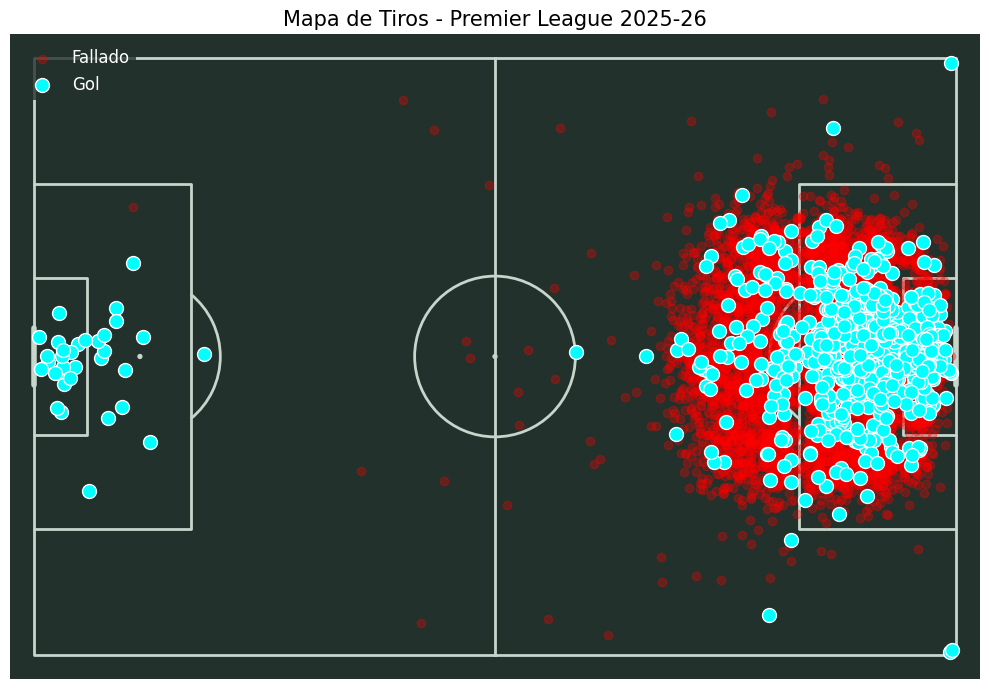

In [4]:
# Visualizar la ubicación de los tiros en la cancha
pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# Tiros que fueron gol (Azul) vs Fallados (Rojo)
pitch.scatter(df_shots[df_shots['is_goal'] == False]['x'], 
              df_shots[df_shots['is_goal'] == False]['y'], 
              ax=ax, color='red', alpha=0.3, label='Fallado')
pitch.scatter(df_shots[df_shots['is_goal'] == True]['x'], 
              df_shots[df_shots['is_goal'] == True]['y'], 
              ax=ax, color='cyan', edgecolors='white', s=100, label='Gol')

ax.legend(facecolor='#22312b', edgecolor='None', fontsize=12, labelcolor='white')
plt.title('Mapa de Tiros - Premier League 2025-26', color='black', fontsize=15)
plt.show()

## 3. EDA: Predicción de Partidos

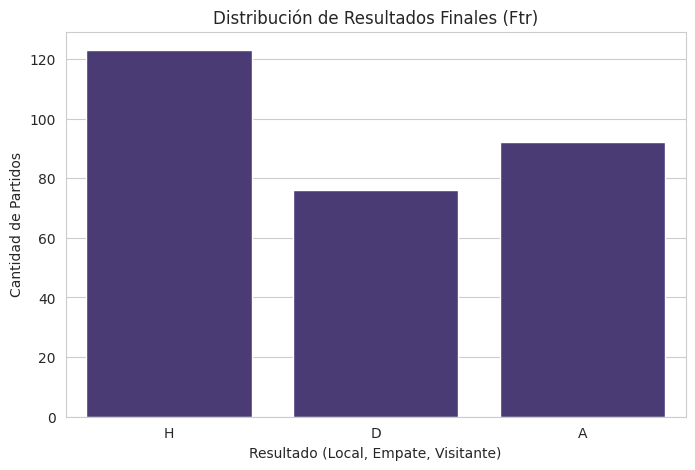

ftr
H    0.422680
A    0.316151
D    0.261168
Name: proportion, dtype: float64


In [5]:
# Distribución de resultados (Home, Draw, Away)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_matches, x='ftr', order=['H', 'D', 'A'])
plt.title('Distribución de Resultados Finales (Ftr)')
plt.xlabel('Resultado (Local, Empate, Visitante)')
plt.ylabel('Cantidad de Partidos')
plt.show()

print(df_matches['ftr'].value_counts(normalize=True))

## 4. Feature Engineering: Preparando el Modelo xG
Extracción de calificadores y cálculo de métricas geométricas.

In [6]:
def parse_shot_qualifiers(qual_str):
    """Extrae características clave del JSON de qualifiers para un tiro."""
    try:
        quals = json.loads(qual_str)
        q_ids = [q['type']['value'] for q in quals]
        return {
            'is_big_chance': 214 in q_ids,
            'is_header': 15 in q_ids,
            'is_counter': 23 in q_ids,
            'is_penalty': 9 in q_ids,
            'is_free_kick': 26 in q_ids
        }
    except:
        return {'is_big_chance': False, 'is_header': False, 'is_counter': False, 'is_penalty': False, 'is_free_kick': False}

# Aplicar la extracción
quals_df = df_shots['qualifiers'].apply(parse_shot_qualifiers).apply(pd.Series)
df_shots = pd.concat([df_shots, quals_df], axis=1)

# Calcular Distancia y Ángulo (Centro de portería en 100, 50)
df_shots['distance'] = np.sqrt((100 - df_shots['x'])**2 + (50 - df_shots['y'])**2)
df_shots['angle'] = np.arctan2(abs(50 - df_shots['y']), (100 - df_shots['x']))

print("Nuevas columnas añadidas:", quals_df.columns.tolist() + ['distance', 'angle'])
df_shots[['is_goal', 'is_big_chance', 'distance', 'angle']].head()

Nuevas columnas añadidas: ['is_big_chance', 'is_header', 'is_counter', 'is_penalty', 'is_free_kick', 'distance', 'angle']


,is_goal,is_big_chance,distance,angle
62,False,False,29.798154,0.678410
89,False,False,23.601907,0.914584
98,False,True,8.614523,0.058074
130,False,True,10.208330,0.511856
185,False,False,10.257680,1.050441


### Correlación de características con el Gol

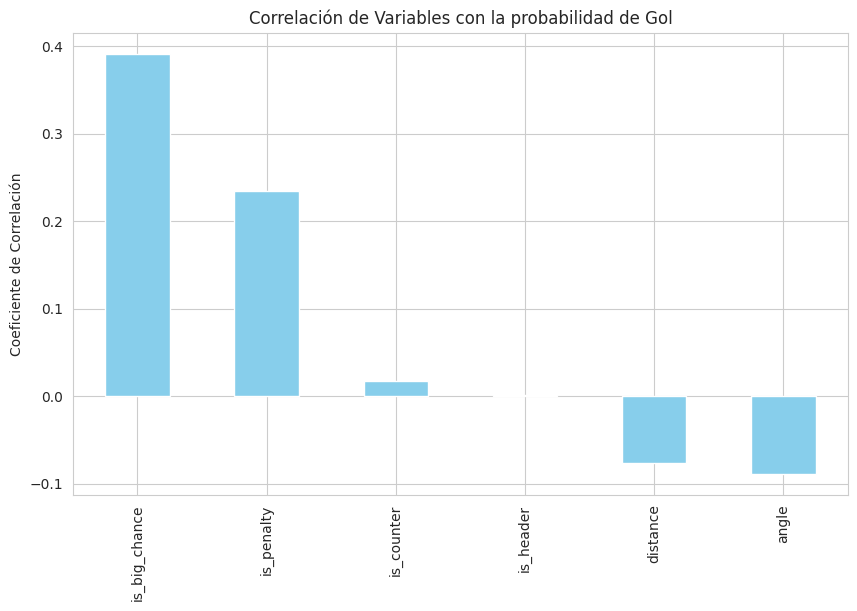

is_goal          1.000000
is_big_chance    0.391611
is_penalty       0.234701
is_counter       0.017641
is_header        0.001602
distance        -0.076540
angle           -0.088682
Name: is_goal, dtype: float64


In [7]:
cols_to_check = ['is_goal', 'distance', 'angle', 'is_big_chance', 'is_header', 'is_counter', 'is_penalty']
correlation = df_shots[cols_to_check].corr()['is_goal'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlation.drop('is_goal').plot(kind='bar', color='skyblue')
plt.title('Correlación de Variables con la probabilidad de Gol')
plt.ylabel('Coeficiente de Correlación')
plt.show()

print(correlation)